In [2]:
import warnings

import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

warnings.simplefilter("ignore")

In [3]:
data_path   = "driftDatasets/artificial/hyperplane/rotatingHyperplane.data"
labels_path = "driftDatasets/artificial/hyperplane/rotatingHyperplane.labels"

X = np.loadtxt(data_path)            # features: a table, one row per instance
y = np.loadtxt(labels_path).astype(int)  # labels: 0 or 1, one per instance

print("Feature table shape:", X.shape)   # (rows, columns) = (instances, features)
print("Labels shape:", y.shape)

Feature table shape: (200000, 10)
Labels shape: (200000,)


In [4]:
print("First 3 rows of features:\n", X[:3])
print("\nNumber of features:", X.shape[1])
print("First 10 labels:", y[:10])
print("Class balance:", np.bincount(y))   # how many of each class

First 3 rows of features:
 [[0.397174 0.347518 0.294057 0.506484 0.115967 0.770536 0.659893 0.156747
  0.378202 0.139763]
 [0.27503  0.075388 0.610592 0.954931 0.274069 0.190202 0.001299 0.683527
  0.48626  0.487515]
 [0.233156 0.889909 0.038327 0.592379 0.655174 0.119839 0.652477 0.984323
  0.206738 0.37465 ]]

Number of features: 10
First 10 labels: [0 0 1 0 0 0 1 0 1 1]
Class balance: [100065  99935]


In [5]:
def mean_abs_shap(shap_values, n_features):
    sv = np.abs(np.array(shap_values))
    # find the axis whose length equals the number of features, average over the rest
    feat_axis = [ax for ax, size in enumerate(sv.shape) if size == n_features][-1]
    other_axes = tuple(ax for ax in range(sv.ndim) if ax != feat_axis)
    return sv.mean(axis=other_axes)   # -> one importance number per feature

In [6]:
def windowed_importance(X, y, window=1000, sample=200, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    n_windows = n // window

    retrained_imp, frozen_imp, frozen_acc, centers = [], [], [], []
    fixed_model = None   # trained on window 0, then never updated (the "deployed" model)

    for w in range(n_windows):
        lo, hi = w * window, (w + 1) * window
        Xw, yw = X[lo:hi], y[lo:hi]
        if len(np.unique(yw)) < 2:
            continue

        m = min(sample, len(Xw))
        idx = rng.choice(len(Xw), m, replace=False)

        # --- track 1: model RETRAINED on this window (the concept's "true" reliance) ---
        clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=seed)
        clf.fit(Xw, yw)
        sv  = shap.TreeExplainer(clf).shap_values(Xw[idx])
        imp = mean_abs_shap(sv, d)
        retrained_imp.append(imp / imp.sum())
        centers.append((lo + hi) // 2)

        # --- track 2: the FROZEN window-0 model seeing this window's incoming data ---
        if fixed_model is None:
            fixed_model = clf                    # deploy the window-0 model
            frozen_imp.append(imp / imp.sum())   # its own fingerprint at t0
            frozen_acc.append(np.nan)            # nothing to compare against yet
        else:
            sv_f  = shap.TreeExplainer(fixed_model).shap_values(Xw[idx])
            imp_f = mean_abs_shap(sv_f, d)
            frozen_imp.append(imp_f / imp_f.sum())
            frozen_acc.append(fixed_model.score(Xw, yw))

    return (np.array(retrained_imp), np.array(frozen_imp),
            np.array(frozen_acc), np.array(centers))

retrained_imp, frozen_imp, fixed_acc, centers = windowed_importance(X, y, window=1000)
print("Computed importances for", len(centers), "windows.")

Computed importances for 200 windows.


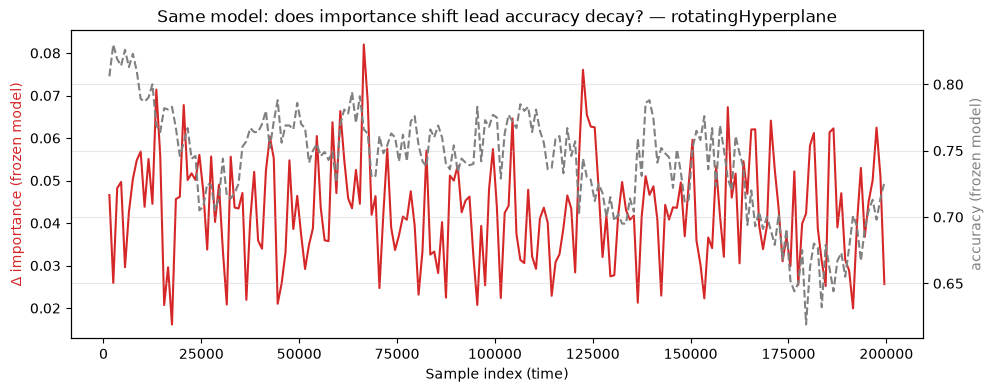

In [7]:
# RQ2: does the frozen model's importance fingerprint move BEFORE its accuracy falls?
delta_frozen = np.r_[np.nan, np.abs(np.diff(frozen_imp, axis=0)).sum(axis=1)]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(centers, delta_frozen, color="tab:red", label="Δ frozen-model importance")
ax1.set_xlabel("Sample index (time)")
ax1.set_ylabel("Δ importance (frozen model)", color="tab:red")

ax2 = ax1.twinx()
ax2.plot(centers, fixed_acc, color="gray", linestyle="--", label="frozen-model accuracy")
ax2.set_ylabel("accuracy (frozen model)", color="gray")

plt.title("Same model: does importance shift lead accuracy decay? — rotatingHyperplane")
plt.grid(alpha=0.3)
plt.show()

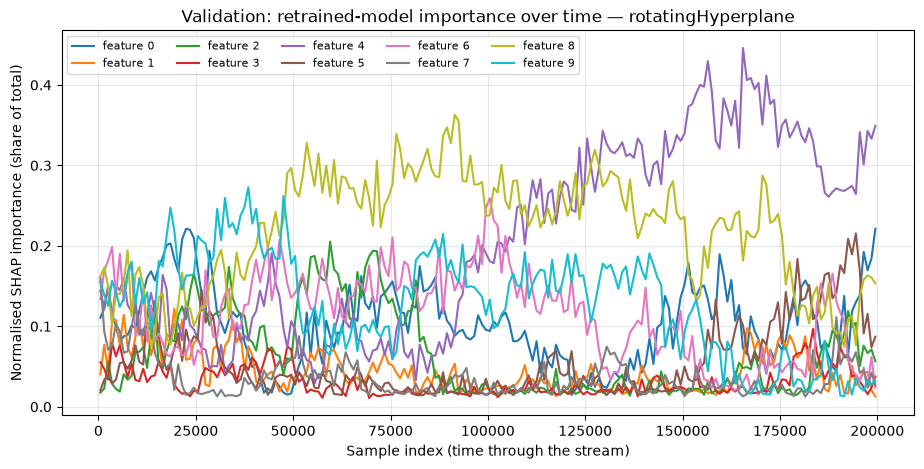

In [8]:
d = X.shape[1]
plt.figure(figsize=(11, 5))
for i in range(d):
    plt.plot(centers, retrained_imp[:, i], label=f"feature {i}")
plt.xlabel("Sample index (time through the stream)")
plt.ylabel("Normalised SHAP importance (share of total)")
plt.title("Validation: retrained-model importance over time — rotatingHyperplane")
plt.legend(ncol=5, fontsize=8)
plt.grid(alpha=0.3)
plt.show()

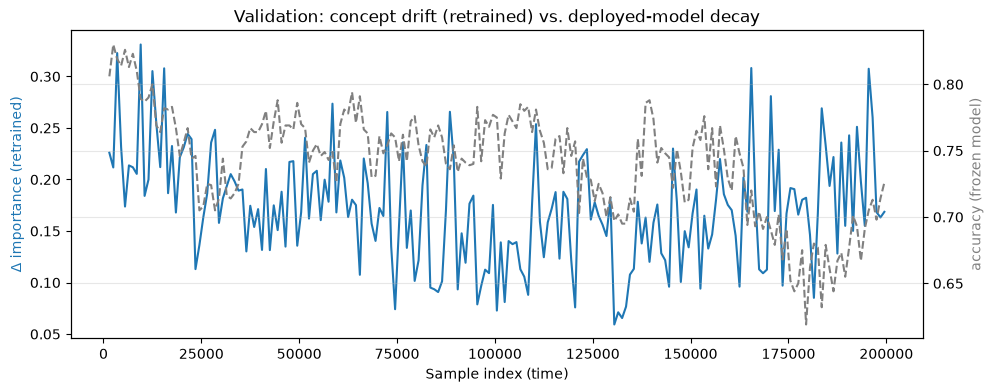

In [9]:
# VALIDATION view: retrained importance movement (concept truly drifting?)
# vs. frozen-model accuracy. Two different models — context only, not the RQ2 test.
delta_retrained = np.r_[np.nan, np.abs(np.diff(retrained_imp, axis=0)).sum(axis=1)]

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(centers, delta_retrained, color="tab:blue", label="Δ retrained importance")
ax1.set_ylabel("Δ importance (retrained)", color="tab:blue")
ax1.set_xlabel("Sample index (time)")

ax2 = ax1.twinx()
ax2.plot(centers, fixed_acc, color="gray", linestyle="--")
ax2.set_ylabel("accuracy (frozen model)", color="gray")
plt.title("Validation: concept drift (retrained) vs. deployed-model decay")
plt.grid(alpha=0.3)
plt.show()

In [10]:
for name, arr in [("retrained", retrained_imp), ("frozen", frozen_imp)]:
    swing = arr.max(axis=0) - arr.min(axis=0)
    print(f"{name} importance swing per feature:", np.round(swing, 3))
    print(f"  largest swing: {round(swing.max(), 3)}")

retrained importance swing per feature: [0.207 0.109 0.192 0.086 0.417 0.201 0.239 0.148 0.288 0.26 ]
  largest swing: 0.417
frozen importance swing per feature: [0.023 0.013 0.006 0.012 0.026 0.009 0.03  0.029 0.029 0.035]
  largest swing: 0.035
